## Reglas de asociación - Reglas

Se generan las reglas en base al soporte, y se calcula la confianza, interés y lift

### Imports

In [1]:
import itertools
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})

### Utilidades

- Constantes

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
canastas_dir = proyecto / "04_Asociacion" / "temp" / "a_canastas"
itemsets_dir = proyecto / "04_Asociacion" / "temp" / "b_itemsets"
out_dir = proyecto / "04_Asociacion" / "temp" / "c_reglas"
out_dir.mkdir(parents=True, exist_ok=True)

- Spark

In [3]:
spark = (SparkSession.builder
         .appName("asociacion-reglas")
         .master("local[*]")
         .config("spark.sql.session.timeZone", "America/Lima")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

---
### 1. Carga de itemsets

Se cargan las canastas desde `temp/b_itemsets/`

In [4]:
assert (itemsets_dir / "fpg_full").exists(), "Corre b_itemsets.ipynb (Run All) antes que este notebook."

itemsets_apriori_q4 = spark.read.parquet(str(itemsets_dir / "apriori_q4")).toPandas()
itemsets_fpg_full = spark.read.parquet(str(itemsets_dir / "fpg_full")).toPandas()

canastas_q4 = spark.read.parquet(str(canastas_dir / "q4_2025"))
canastas_full = spark.read.parquet(str(canastas_dir / "full"))
n_q4, n_full = canastas_q4.count(), canastas_full.count()

print(f"Itemsets Apriori (Q4): {len(itemsets_apriori_q4):,} | Itemsets FP-Growth (completo): {len(itemsets_fpg_full):,}")

Itemsets Apriori (Q4): 300 | Itemsets FP-Growth (completo): 317


### 2. Soportes base de ítems individuales

Q4 se calcula fresco (no existe una versión Q4 de `support_full`). El del dataset completo se
reusa de `a_canastas.ipynb` §3.b (`support_full`) en vez de recalcularlo.

In [5]:
def soportes_base(canastas_df, n):
    filas = (canastas_df.select(F.explode("canasta").alias("item"))
             .groupBy("item").count()
             .withColumn("support", F.col("count") / n)
             .select("item", "support").collect())
    return {r["item"]: r["support"] for r in filas}

soportes_q4 = soportes_base(canastas_q4, n_q4)

support_full_pd = spark.read.parquet(str(canastas_dir / "support_full")).toPandas()
soportes_full = dict(zip(support_full_pd["item"], support_full_pd["soporte_abs"] / n_full))

print(f"Ítems con soporte base: Q4={len(soportes_q4)} | completo={len(soportes_full)}")

Ítems con soporte base: Q4=286 | completo=304


---
### 3. Generación de reglas

- Auxiliar

In [6]:
def generar_reglas(itemsets_df, soportes_item):
    """itemsets_df: columnas 'items' (lista) y 'support' (float).
    soportes_item: dict {item: soporte} de items individuales, sobre la misma base N.
    Devuelve TODAS las reglas candidatas (todas las particiones antecedente/consecuente con
    soporte disponible), sin filtrar por confianza -- eso se decide después, con evidencia.
    """
    soporte_itemset = {frozenset(row["items"]): row["support"] for _, row in itemsets_df.iterrows()}

    filas = []
    for _, row in itemsets_df.iterrows():
        items = frozenset(row["items"])
        if len(items) < 2:
            continue
        sup_ab = row["support"]

        for r in range(1, len(items)):
            for ant in itertools.combinations(items, r):
                antecedente = frozenset(ant)
                consecuente = items - antecedente

                if len(antecedente) == 1:
                    sup_a = soportes_item.get(next(iter(antecedente)))
                else:
                    sup_a = soporte_itemset.get(antecedente)
                if not sup_a:
                    continue

                if len(consecuente) == 1:
                    sup_b = soportes_item.get(next(iter(consecuente)))
                else:
                    sup_b = soporte_itemset.get(consecuente)
                if not sup_b:
                    continue

                confianza = sup_ab / sup_a
                lift = confianza / sup_b
                interes = confianza - sup_b
                filas.append({
                    "antecedente": sorted(antecedente), "consecuente": sorted(consecuente),
                    "soporte": sup_ab, "confianza": confianza, "lift": lift, "interes": interes,
                })
    return pd.DataFrame(filas)

- Flujo

In [7]:
todas_apriori = generar_reglas(itemsets_apriori_q4, soportes_q4)
todas_fpg = generar_reglas(itemsets_fpg_full, soportes_full)

print(f"Reglas candidatas (Apriori, Q4 2025)   : {len(todas_apriori):,}")
print(f"Reglas candidatas (FP-Growth, completo): {len(todas_fpg):,}")

Reglas candidatas (Apriori, Q4 2025)   : 1,908
Reglas candidatas (FP-Growth, completo): 1,710


#### Elección de confianza mínima

Igual que con `MIN_SUPPORT` en `b_itemsets.ipynb`: se prueban varios umbrales y se elige con
evidencia, no a ciegas.

In [8]:
sensibilidad_confianza = []
for mc in [0.3, 0.4, 0.5, 0.6, 0.7]:
    n_apriori = int((todas_apriori["confianza"] >= mc).sum())
    n_fpg = int((todas_fpg["confianza"] >= mc).sum())
    sensibilidad_confianza.append((mc, n_apriori, n_fpg))
    print(f"min_confianza={mc:.1f} -> Apriori-Q4={n_apriori:,} | FP-Growth-completo={n_fpg:,}")

min_confianza=0.3 -> Apriori-Q4=998 | FP-Growth-completo=835
min_confianza=0.4 -> Apriori-Q4=763 | FP-Growth-completo=612
min_confianza=0.5 -> Apriori-Q4=579 | FP-Growth-completo=497
min_confianza=0.6 -> Apriori-Q4=475 | FP-Growth-completo=369
min_confianza=0.7 -> Apriori-Q4=419 | FP-Growth-completo=290


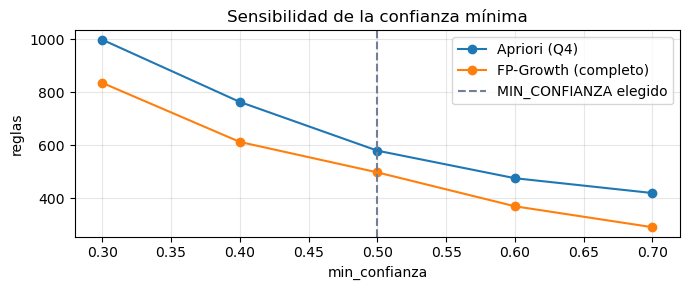

In [9]:
mc_vals, mc_apriori, mc_fpg = zip(*sensibilidad_confianza)
plt.figure(figsize=(7, 3))
plt.plot(mc_vals, mc_apriori, marker="o", label="Apriori (Q4)")
plt.plot(mc_vals, mc_fpg, marker="o", label="FP-Growth (completo)")
plt.axvline(0.5, color="#718096", linestyle="--", label="MIN_CONFIANZA elegido")
plt.xlabel("min_confianza"); plt.ylabel("reglas"); plt.legend()
plt.title("Sensibilidad de la confianza mínima")
plt.tight_layout(); plt.show()

- La caída es gradual, sin un salto brusco: 998→419 (Apriori-Q4) y 835→290 (FP-Growth-completo) entre 0.3 y 0.7

- Se fija `MIN_CONFIANZA=0.5` — a mitad de camino, deja ambas tablas bien pobladas (579 y 497 reglas) sin aceptar reglas tan débiles como para que la mitad de las veces el antecedente no prediga el consecuente

#### Redundancia entre reglas

Una regla `{A,B} → {C}` es redundante si alguna de sus simplificaciones inmediatas (`{A} → {C}` o
`{B} → {C}`) ya tiene confianza igual o mayor — agregar el ítem extra no mejoró la predicción. Se
marca (columna `redundante`) pero no se descarta; es información de calidad, no un filtro.

In [10]:
def marcar_redundantes(reglas):
    lookup = {(frozenset(r["antecedente"]), frozenset(r["consecuente"])): r["confianza"]
              for _, r in reglas.iterrows()}

    def es_redundante(row):
        ant = frozenset(row["antecedente"])
        if len(ant) < 2:
            return False
        con = frozenset(row["consecuente"])
        mejor_simple = max((lookup.get((ant - {item}, con), 0.0) for item in ant), default=0.0)
        return row["confianza"] <= mejor_simple

    return reglas.assign(redundante=reglas.apply(es_redundante, axis=1))

todas_apriori = marcar_redundantes(todas_apriori)
todas_fpg = marcar_redundantes(todas_fpg)

print(f"Redundantes (Apriori, Q4 2025)   : {int(todas_apriori['redundante'].sum()):,} de {len(todas_apriori):,}")
print(f"Redundantes (FP-Growth, completo): {int(todas_fpg['redundante'].sum()):,} de {len(todas_fpg):,}")

Redundantes (Apriori, Q4 2025)   : 550 de 1,908
Redundantes (FP-Growth, completo): 387 de 1,710


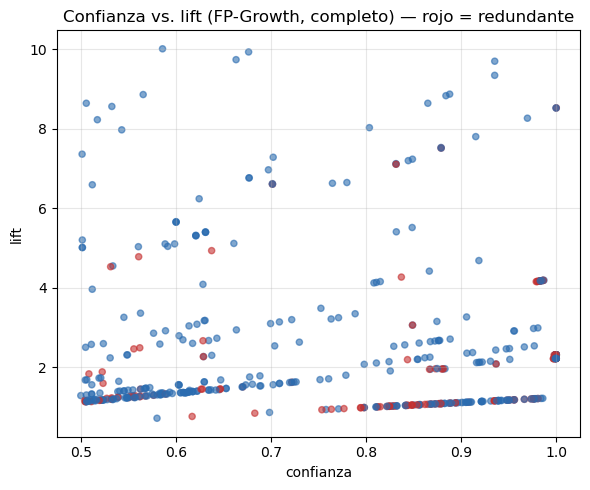

In [11]:
muestra = todas_fpg[todas_fpg["confianza"] >= 0.5]
colores = muestra["redundante"].map({True: "#c53030", False: "#2b6cb0"})

plt.figure(figsize=(6, 5))
plt.scatter(muestra["confianza"], muestra["lift"], c=colores, alpha=0.6, s=20)
plt.xlabel("confianza"); plt.ylabel("lift")
plt.title("Confianza vs. lift (FP-Growth, completo) — rojo = redundante")
plt.tight_layout(); plt.show()

- Sobre todas las candidatas (sin filtrar por confianza todavía), 550 de 1,908 (28.8%) en Apriori-Q4 y 387 de 1,710 (22.6%) en FP-Growth-completo son redundantes

- Proporciones similares, consistente con que ambos algoritmos minan la misma estructura de co-ocurrencia subyacente, solo que sobre universos distintos (subconjunto vs. completo)

#### Reglas finales (filtradas por confianza mínima)

In [12]:
MIN_CONFIANZA = 0.5

reglas_apriori_q4 = todas_apriori[todas_apriori["confianza"] >= MIN_CONFIANZA].copy()
reglas_fpg_full = todas_fpg[todas_fpg["confianza"] >= MIN_CONFIANZA].copy()

print(f"Reglas (Apriori, Q4 2025)   : {len(reglas_apriori_q4):,} "
      f"({int(reglas_apriori_q4['redundante'].sum())} redundantes)")
print(f"Reglas (FP-Growth, completo): {len(reglas_fpg_full):,} "
      f"({int(reglas_fpg_full['redundante'].sum())} redundantes)")
reglas_fpg_full.sort_values("lift", ascending=False).head(10)

Reglas (Apriori, Q4 2025)   : 579 (241 redundantes)
Reglas (FP-Growth, completo): 497 (140 redundantes)


,antecedente,consecuente,soporte,confianza,lift,interes,redundante
1499,"[comp=postor_unico, monto=2_50k-200k]",[met=CONTRATACIÓN DIRECTA],0.023191,0.585966,10.012178,0.527440,False
1009,"[reg=LIMA, rubro=80]","[cat=SERVICES, comp=postor_unico]",0.026479,0.676503,9.932917,0.608396,False
439,"[monto=1_<50k, reg=LIMA]","[cat=SERVICES, comp=postor_unico]",0.020734,0.663299,9.739047,0.595192,False
1232,"[met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]","[cat=WORKS, comp=varios_postores]",0.024333,0.935318,9.699986,0.838893,False
1501,"[met=CONTRATACIÓN DIRECTA, monto=2_50k-200k]",[comp=postor_unico],0.023191,0.935276,9.344874,0.835191,False
1507,"[met=CONTRATACIÓN DIRECTA, reg=LIMA]",[comp=postor_unico],0.025744,0.887944,8.871955,0.787860,False
438,"[cat=SERVICES, monto=1_<50k]","[comp=postor_unico, reg=LIMA]",0.020734,0.565612,8.861390,0.501784,False
1495,"[cat=SERVICES, met=CONTRATACIÓN DIRECTA]",[comp=postor_unico],0.031782,0.884009,8.832641,0.783925,False
1488,[comp=postor_unico],[met=CONTRATACIÓN DIRECTA],0.050622,0.505792,8.642277,0.447267,False
1489,[met=CONTRATACIÓN DIRECTA],[comp=postor_unico],0.050622,0.864957,8.642277,0.764872,False


- Del total que cumple `confianza>=0.5`, el 41.6% de Apriori-Q4 (241 de 579) y el 28.2% de FP-Growth-completo (140 de 497) son redundantes — la mayoría sí aporta algo sobre su versión más simple

- Entre las top 10 por lift (mostradas arriba) **ninguna es redundante**: cada combinación de 2 ítems supera a sus dos simplificaciones de 1 ítem, confirmando que no son solo ruido estadístico de agregar un ítem más al antecedente

---
### 4. Métrica propia: interés

**Interés** (métrica propia, no pedida por el enunciado — soporte/confianza/lift sí lo son):
`interés(A→B) = confianza(A→B) − soporte(B)`. Mide la desviación aditiva respecto a independencia
(si interés=0, A no cambia la probabilidad de B; valores positivos indican asociación positiva).
Complementa al lift (razón multiplicativa): cuando `soporte(B)` ya es alto (ej. `comp=varios_postores`
con 80.9%), el lift se comprime cerca de 1 aunque el salto absoluto de probabilidad sea grande —
interés capta esa magnitud absoluta.

---
### 5. Escritura a `temp/c_reglas/`

In [13]:
def a_spark(df):
    return spark.createDataFrame(df.assign(
        antecedente=df["antecedente"].apply(list),
        consecuente=df["consecuente"].apply(list),
    ))

a_spark(reglas_apriori_q4).write.mode("overwrite").parquet(str(out_dir / "apriori_q4"))
a_spark(reglas_fpg_full).write.mode("overwrite").parquet(str(out_dir / "fpg_full"))
print("Escrito en temp/c_reglas/: apriori_q4, fpg_full")

Escrito en temp/c_reglas/: apriori_q4, fpg_full


---
### 6. Verificación: chequeo cruzado con Parte I

`b_exploracion.ipynb` ya halló que `metodo_detalle=Contratación Directa` tiene 86.5% de postor
único. Si la regla `{met=CONTRATACIÓN DIRECTA} → {comp=postor_unico}` existe aquí, su confianza
debería coincidir — es la validación de que el pipeline de reglas está bien construido.

In [14]:
objetivo = reglas_fpg_full[
    reglas_fpg_full["antecedente"].apply(lambda a: a == ["met=CONTRATACIÓN DIRECTA"]) &
    reglas_fpg_full["consecuente"].apply(lambda c: c == ["comp=postor_unico"])
]
objetivo

,antecedente,consecuente,soporte,confianza,lift,interes,redundante
1489,[met=CONTRATACIÓN DIRECTA],[comp=postor_unico],0.050622,0.864957,8.642277,0.764872,False


- Confianza = 0.864957 (86.5%) — coincide exactamente con el 86.5% ya hallado en `b_exploracion.ipynb` §5.4 para `metodo_detalle=Contratación Directa`

- Valida que la función `generar_reglas` está bien construida: reproduce, desde itemsets frecuentes y soportes base, un número que se había calculado de forma completamente independiente (un `groupBy`/`avg` directo sobre la columna original)

---
### 7. Cerrar sesión de Spark

In [15]:
spark.stop()